```
Imagen → ResNet18 backbone → Proyección → Embedding → OneClassSVM → Normal / Defecto
```

## 0. Instalación de librerías

## 1. Importación de librerias, dataset y configuración general

In [ ]:
import kagglehub
from pathlib import Path

# Descarga el dataset MVTec-AD desde Kaggle
path = kagglehub.dataset_download("ipythonx/mvtec-ad")
category = "cable"   # Cambia aquí la categoría: bottle, cable, capsule, carpet, grid, ...
print("Path al dataset:", path)

category_path = Path(path) / category
print("Path de categoría:", category_path)

100%|██████████| 4.91G/4.91G [00:49<00:00, 107MB/s] 

Extracting files...


Path al dataset: /root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2
Path de categoría: /root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2/cable


In [2]:
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.datasets.folder import default_loader
from tqdm import tqdm

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import mlflow
import mlflow.sklearn

import os

def fijar_semillas(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


fijar_semillas(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

KeyboardInterrupt: 

In [6]:
import os
from dotenv import load_dotenv
import mlflow

load_dotenv()

DATABRICKS_TOKEN = os.getenv('DATABRICKS_TOKEN')
DATABRICKS_HOST = os.getenv('DATABRICKS_HOST')
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
MLFLOW_EXPERIMENT_ID = os.getenv('ID_SIAMESA')

os.environ['DATABRICKS_TOKEN'] = DATABRICKS_TOKEN
os.environ['DATABRICKS_HOST'] = DATABRICKS_HOST
os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_TRACKING_URI
os.environ['MLFLOW_EXPERIMENT_ID'] = MLFLOW_EXPERIMENT_ID

mlflow.set_experiment(os.getenv('EXPERIMENT_SIAMESE'));

AttributeError: partially initialized module 'mlflow' from 'c:\Users\fanny\OneDrive\Documentos\_MCD\rnn\proyectos\cnn_mvtec\defect-vision\defect-vision\.venv\Lib\site-packages\mlflow\__init__.py' has no attribute 'version' (most likely due to a circular import)

## 2. Preprocesamiento de dataset

In [ ]:
# Explorar la estructura del dataset para la categoría seleccionada
category_path = Path(path) / category

print(f"=== Estructura de '{category}' ===")
for split in ['train', 'test']:
    split_path = category_path / split
    if split_path.exists():
        subcarpetas = list(split_path.iterdir())
        print(f"\n{split}/")
        for sub in subcarpetas:
            n_imgs = len(list(sub.glob('*.png')) + list(sub.glob('*.jpg')))
            print(f"  {sub.name}/  ({n_imgs} imágenes)")

=== Estructura de 'cable' ===

train/
  good/  (224 imágenes)

test/
  missing_wire/  (10 imágenes)
  bent_wire/  (13 imágenes)
  missing_cable/  (12 imágenes)
  good/  (58 imágenes)
  combined/  (11 imágenes)
  cable_swap/  (12 imágenes)
  cut_inner_insulation/  (14 imágenes)
  poke_insulation/  (10 imágenes)
  cut_outer_insulation/  (10 imágenes)


## Dataset en triplets

In [ ]:
class MVTecTripletDataset(Dataset):
    """
    Dataset de tripletes self-supervised para MVTec-AD.
    Solo usa imágenes normales de entrenamiento.

    Tripletes:
      - Anchor  : imagen normal con transform básico
      - Positive: misma imagen con augmentation fuerte
      - Negative: crop de región pequeña de otra imagen (distribución distinta)
    """

    def __init__(self, root_dir: str, transform_base=None, transform_aug=None):
        self.root_dir = Path(root_dir)
        self.image_paths = sorted(
            list(self.root_dir.glob('**/*.png')) +
            list(self.root_dir.glob('**/*.jpg'))
        )
        assert len(self.image_paths) > 0, f"No se encontraron imágenes en {root_dir}"

        self.transform_base = transform_base
        self.transform_aug = transform_aug
        self.loader = default_loader

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Anchor
        anchor_path = self.image_paths[idx]
        anchor_pil = self.loader(anchor_path)

        # Positive: misma imagen con augmentation fuerte
        positive_pil = anchor_pil.copy()

        # Negative: otra imagen aleatoria diferente al anchor
        neg_idx = random.choice([i for i in range(len(self.image_paths)) if i != idx])
        negative_pil = self.loader(self.image_paths[neg_idx])

        anchor_t   = self.transform_base(anchor_pil)   if self.transform_base else anchor_pil
        positive_t = self.transform_aug(positive_pil)  if self.transform_aug  else positive_pil
        negative_t = self.transform_aug(negative_pil)  if self.transform_aug  else negative_pil

        return anchor_t, positive_t, negative_t


class MVTecTestDataset(Dataset):
    """
    Dataset para evaluación: carga imágenes de test con etiqueta binaria.
    label=0 → normal, label=1 → defecto
    """

    def __init__(self, test_dir: str, transform=None):
        self.test_dir = Path(test_dir)
        self.transform = transform
        self.loader = default_loader

        self.samples = []  # (path, label)
        for subdir in sorted(self.test_dir.iterdir()):
            if not subdir.is_dir():
                continue
            label = 0 if subdir.name == 'good' else 1
            for img_path in sorted(
                list(subdir.glob('*.png')) + list(subdir.glob('*.jpg'))
            ):
                self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = self.loader(img_path)
        if self.transform:
            img = self.transform(img)
        return img, label

## 4. Modelo de redes ResNet18 siamesas

In [ ]:
class SiameseEmbeddingNet(nn.Module):
    """Red siamesa con backbone ResNet18 preentrenado."""

    def __init__(self, embedding_dim: int = 128, usar_preentrenado: bool = True,
                 entrenar_backbone: bool = False):
        super().__init__()

        try:
            weights = models.ResNet18_Weights.DEFAULT if usar_preentrenado else None
            backbone = models.resnet18(weights=weights)
        except Exception as exc:
            print(f'[Aviso] No se pudieron cargar pesos preentrenados: {exc}')
            backbone = models.resnet18(weights=None)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.proyeccion = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, embedding_dim),
        )

        if not entrenar_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward_once(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        emb = self.proyeccion(features)
        return F.normalize(emb, p=2, dim=1)

    def forward(self, anchor, positive, negative):
        return (
            self.forward_once(anchor),
            self.forward_once(positive),
            self.forward_once(negative),
        )

## 5. Función de Pérdida KL / Tripletes

In [ ]:
def perdida_kl_tripletes(
    emb_a, emb_p, emb_n,
    temperatura: float = 0.1,
    tipo: str = 'kl'
):
    dist_ap = F.pairwise_distance(emb_a, emb_p)
    dist_an = F.pairwise_distance(emb_a, emb_n)

    logits = torch.stack((-dist_ap / temperatura, -dist_an / temperatura), dim=1)
    log_probs = F.log_softmax(logits, dim=1)

    target = torch.zeros_like(log_probs)
    target[:, 0] = 1.0

    if tipo == 'kl':
        loss = F.kl_div(log_probs, target, reduction='batchmean')
    else:
        loss = F.triplet_margin_loss(emb_a, emb_p, emb_n)

    with torch.no_grad():
        pred = log_probs.argmax(dim=1)
        acc  = (pred == 0).float().mean()

    return loss, acc, dist_ap.mean(), dist_an.mean()

## 6. Configuración e Hiperparámetros

In [ ]:
@dataclass
class Config:
    # Dataset
    mvtec_path: str = path          # ruta base descargada por kagglehub
    category: str = category        # categoría MVTec: 'cable', 'bottle', etc.

    # Modelo
    embedding_dim: int = 128
    usar_preentrenado: bool = True
    entrenar_backbone: bool = False

    # Entrenamiento siamés
    batch_size: int = 32
    epochs: int = 10
    lr: float = 1e-3
    criterion: str = 'kl'           # 'kl' o 'tripletas'
    temperatura_kl: float = 0.1
    num_workers: int = 2

    # OneClassSVM
    ocsvm_kernel: str = 'rbf'       # 'rbf', 'linear', 'poly'
    ocsvm_nu: float = 0.05          # proporción de outliers/ruido esperados
    ocsvm_gamma: str = 'scale'      # 'scale', 'auto' o float


cfg = Config()
print(cfg)

Config(mvtec_path='/root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2', category='cable', embedding_dim=128, usar_preentrenado=True, entrenar_backbone=False, batch_size=32, epochs=10, lr=0.001, criterion='kl', temperatura_kl=0.1, num_workers=2, ocsvm_kernel='rbf', ocsvm_nu=0.01, ocsvm_gamma='scale', nombre='Testing_mlflow_structure')


## 7. Transforms y DataLoaders

In [ ]:
# Transformaciones estándar de ResNet18
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Augmentations para generar los positivos
transform_aug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def crear_dataloaders(cfg: Config):
    base_path  = Path(cfg.mvtec_path) / cfg.category
    train_path = base_path / 'train' / 'good'
    test_path  = base_path / 'test'

    # Dataset de entrenamiento (solo normales, tripletes self-supervised)
    train_ds = MVTecTripletDataset(
        root_dir=str(train_path),
        transform_base=transform_base,
        transform_aug=transform_aug,
    )

    # Dataset de evaluación (normales + defectos)
    test_ds = MVTecTestDataset(
        test_dir=str(test_path),
        transform=transform_base,
    )

    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size,
        shuffle=True, num_workers=cfg.num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg.batch_size,
        shuffle=False, num_workers=cfg.num_workers, pin_memory=True
    )

    print(f"Train: {len(train_ds)} imágenes normales")
    print(f"Test : {len(test_ds)} imágenes (normales + defectos)")
    n_normal  = sum(1 for _, l in test_ds.samples if l == 0)
    n_defecto = sum(1 for _, l in test_ds.samples if l == 1)
    print(f"  → Test normales={n_normal}, defectos={n_defecto}")

    return train_loader, test_loader


train_loader, test_loader = crear_dataloaders(cfg)

Train: 224 imágenes normales
Test : 150 imágenes (normales + defectos)
  → Test normales=58, defectos=92


## 8. Función de entrenamiento


In [ ]:
def ejecutar_epoca(model, dataloader, device, optimizer, temperatura_kl, criterio):
    entrenando = optimizer is not None
    model.train(entrenando)

    total_loss, total_acc = 0.0, 0.0
    total_dist_ap, total_dist_an = 0.0, 0.0
    total_batches = 0

    # MVTec devuelve (anchor, positive, negative) sin etiqueta de clase
    for batch in tqdm(dataloader, leave=False):
        anchor, positive, negative = batch[0], batch[1], batch[2]
        anchor   = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)
        negative = negative.to(device, non_blocking=True)

        if entrenando:
            optimizer.zero_grad()

        with torch.set_grad_enabled(entrenando):
            emb_a, emb_p, emb_n = model(anchor, positive, negative)
            loss, acc, dist_ap, dist_an = perdida_kl_tripletes(
                emb_a, emb_p, emb_n,
                temperatura=temperatura_kl, tipo=criterio
            )
            if entrenando:
                loss.backward()
                optimizer.step()

        total_loss    += loss.item()
        total_acc     += acc.item()
        total_dist_ap += dist_ap.item()
        total_dist_an += dist_an.item()
        total_batches += 1

    return {
        'loss':    total_loss    / total_batches,
        'acc':     total_acc     / total_batches,
        'dist_ap': total_dist_ap / total_batches,
        'dist_an': total_dist_an / total_batches,
    }

## 9. Entrenamiento de la Red Siamesa

In [ ]:
import dataclasses

In [ ]:
model = SiameseEmbeddingNet(
    embedding_dim=cfg.embedding_dim,
    usar_preentrenado=cfg.usar_preentrenado,
    entrenar_backbone=cfg.entrenar_backbone,
).to(device)

parametros_entrenables = [p for p in model.parameters() if p.requires_grad]
print(f"Parámetros entrenables: {sum(p.numel() for p in parametros_entrenables):,}")

optimizer = torch.optim.Adam(parametros_entrenables, lr=cfg.lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

Parámetros entrenables: 328,320


In [ ]:
historia = []

for epoch in range(1, cfg.epochs + 1):
    print(f"\n[Epoch {epoch}/{cfg.epochs}] Entrenando...")
    train_m = ejecutar_epoca(
        model, train_loader, device, optimizer,
        cfg.temperatura_kl, cfg.criterion
    )
    scheduler.step()
    historia.append(train_m)

    print(
        f"  loss={train_m['loss']:.4f} | "
        f"acc={train_m['acc']:.4f} | "
        f"d(a,p)={train_m['dist_ap']:.4f} | "
        f"d(a,n)={train_m['dist_an']:.4f}"
    )

    mlflow.log_params(dataclasses.asdict(cfg))
    mlflow.log_metrics({
            "train_loss":    train_m["loss"],
            "train_acc":     train_m["acc"],
            "train_dist_ap": train_m["dist_ap"],
            "train_dist_an": train_m["dist_an"],
        }, step=epoch)

print("\nEntrenamiento completado.")


[Epoch 1/10] Entrenando...


  loss=0.6905 | acc=0.5670 | d(a,p)=0.6843 | d(a,n)=0.6977

[Epoch 2/10] Entrenando...


  loss=0.6833 | acc=0.5714 | d(a,p)=0.5341 | d(a,n)=0.5463

[Epoch 3/10] Entrenando...


  loss=0.6866 | acc=0.5938 | d(a,p)=0.4808 | d(a,n)=0.4922

[Epoch 4/10] Entrenando...


  loss=0.6901 | acc=0.5759 | d(a,p)=0.4445 | d(a,n)=0.4534

[Epoch 5/10] Entrenando...


...

  loss=0.6167 | acc=0.6562 | d(a,p)=0.4269 | d(a,n)=0.4527

[Epoch 7/10] Entrenando...


  loss=0.5972 | acc=0.6920 | d(a,p)=0.4395 | d(a,n)=0.4715

[Epoch 8/10] Entrenando...


  loss=0.5871 | acc=0.7009 | d(a,p)=0.4568 | d(a,n)=0.4921

[Epoch 9/10] Entrenando...


  loss=0.6520 | acc=0.6339 | d(a,p)=0.4783 | d(a,n)=0.4996

[Epoch 10/10] Entrenando...


  loss=0.5682 | acc=0.6830 | d(a,p)=0.4675 | d(a,n)=0.5103

Entrenamiento completado.


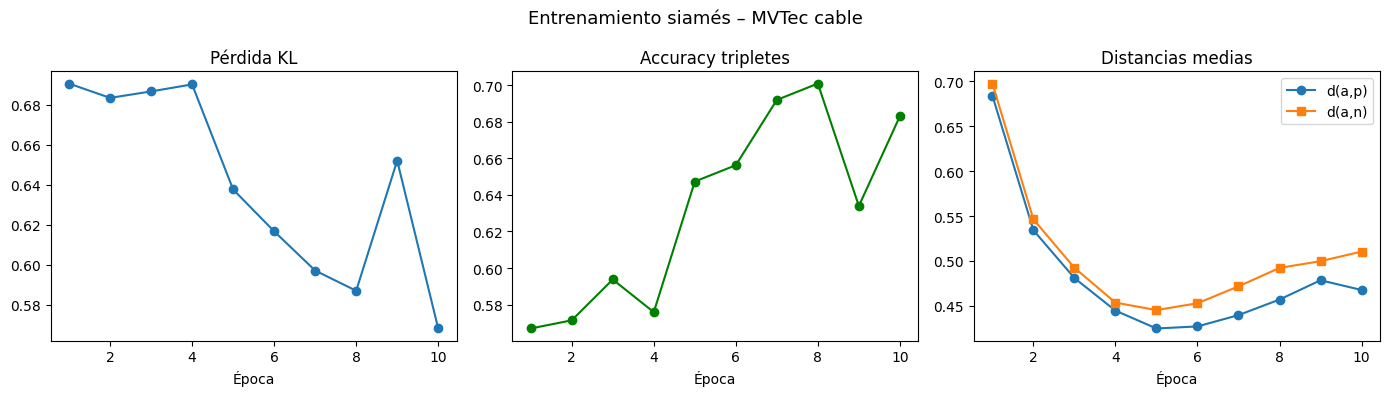

In [ ]:
# Curva de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs_range = range(1, len(historia) + 1)

axes[0].plot(epochs_range, [h['loss'] for h in historia], marker='o')
axes[0].set_title('Pérdida KL'); axes[0].set_xlabel('Época')

axes[1].plot(epochs_range, [h['acc'] for h in historia], marker='o', color='green')
axes[1].set_title('Accuracy tripletes'); axes[1].set_xlabel('Época')

axes[2].plot(epochs_range, [h['dist_ap'] for h in historia], label='d(a,p)', marker='o')
axes[2].plot(epochs_range, [h['dist_an'] for h in historia], label='d(a,n)', marker='s')
axes[2].set_title('Distancias medias'); axes[2].set_xlabel('Época')
axes[2].legend()

plt.suptitle(f'Entrenamiento siamés – MVTec {cfg.category}', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Extracción de Embeddings

Extraemos los embeddings de:
1. Las imágenes de **entrenamiento normales** → para ajustar el OneClassSVM.
2. Las imágenes de **test** (normales + defectos) → para evaluar.

In [ ]:
def extraer_embeddings(model, dataloader, device):
    """Extrae embeddings de un dataloader. Devuelve (embeddings, labels)."""
    model.eval()
    embs, labs = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extrayendo embeddings'):
            # train_loader devuelve (anchor, pos, neg); test_loader devuelve (img, label)
            if isinstance(batch, (list, tuple)) and len(batch) == 3:
                imgs = batch[0]   # solo el anchor
                labels = torch.zeros(imgs.size(0), dtype=torch.long)  # todos normales
            else:
                imgs, labels = batch

            imgs = imgs.to(device, non_blocking=True)
            e = model.forward_once(imgs)
            embs.append(e.cpu().numpy())
            labs.append(labels.numpy() if isinstance(labels, torch.Tensor) else labels)

    return np.concatenate(embs, axis=0), np.concatenate(labs, axis=0)


print("Extrayendo embeddings de entrenamiento (normales)...")
train_embs, train_labels = extraer_embeddings(model, train_loader, device)

print("Extrayendo embeddings de test...")
test_embs, test_labels = extraer_embeddings(model, test_loader, device)

print(f"\nShape train embeddings : {train_embs.shape}")
print(f"Shape test embeddings  : {test_embs.shape}")
print(f"Test labels únicas     : {np.unique(test_labels, return_counts=True)}")

Extrayendo embeddings de entrenamiento (normales)...


Extrayendo embeddings: 100%|██████████| 7/7 [00:21<00:00,  3.14s/it]


Extrayendo embeddings de test...


Extrayendo embeddings: 100%|██████████| 5/5 [00:07<00:00,  1.42s/it]


Shape train embeddings : (224, 128)
Shape test embeddings  : (150, 128)
Test labels únicas     : (array([0, 1]), array([58, 92]))


## 11. OneClassSVM sobre los Embeddings

El **OneClassSVM** aprende la frontera del espacio de embeddings normales. Cualquier punto que caiga fuera de esa frontera se considera **defecto**.

Hiperparámetros clave:
- `nu`: fracción esperada de outliers en los datos de entrenamiento (≈ tasa de falsos positivos aceptable).
- `kernel`: `'rbf'` funciona bien en espacios de embeddings.
- `gamma`: controla la influencia de cada ejemplo de soporte.

In [ ]:
# Normalizar los embeddings antes del SVM
scaler = StandardScaler()
train_embs_scaled = scaler.fit_transform(train_embs)
test_embs_scaled  = scaler.transform(test_embs)

# Entrenar OneClassSVM solo con imágenes normales
print("Entrenando OneClassSVM...")
ocsvm = OneClassSVM(
    kernel=cfg.ocsvm_kernel,
    nu=cfg.ocsvm_nu,
    gamma=cfg.ocsvm_gamma,
)
ocsvm.fit(train_embs_scaled)
print("Entrenamiento finalizado")

# Predicción: +1 = normal, -1 = anomalía
pred_raw   = ocsvm.predict(test_embs_scaled)        # +1 o -1
score_raw  = ocsvm.decision_function(test_embs_scaled)  # distancia a la frontera

# Convertir a etiqueta binaria: 0=normal, 1=defecto
pred_binary = (pred_raw == -1).astype(int)

Entrenando OneClassSVM...
Entrenamiento finalizado


## 12. Evaluación en test set

In [ ]:
# AUC-ROC (usamos el score negado: cuanto más negativo el score, más anómalo)
auc = roc_auc_score(test_labels, -score_raw)
print(f"\n=== Resultados – MVTec '{cfg.category}' ===")
print(f"AUC-ROC : {auc:.4f}")
report_dict = classification_report(test_labels, pred_binary, output_dict=True)
accuracy = report_dict['accuracy']
print(f"Accuracy: {accuracy:.4f}")
print()
print(classification_report(
    test_labels, pred_binary,
    target_names=['Normal', 'Defecto']
))


# Métricas del testing
mlflow.log_metric("test_auc_roc", auc)
mlflow.log_metric("test_acc", accuracy)
mlflow.end_run()


=== Resultados – MVTec 'cable' ===
AUC-ROC : 0.6181
Accuracy: 0.4933

              precision    recall  f1-score   support

      Normal       0.42      0.76      0.54        58
     Defecto       0.68      0.33      0.44        92

    accuracy                           0.49       150
   macro avg       0.55      0.54      0.49       150
weighted avg       0.58      0.49      0.48       150

🏃 View run fearless-grub-174 at: https://dbc-91223b91-1e6c.cloud.databricks.com/ml/experiments/2447687074124058/runs/f08464dc40614dba84832baca8d11cdb
🧪 View experiment at: https://dbc-91223b91-1e6c.cloud.databricks.com/ml/experiments/2447687074124058


## 13. Visualización t-SNE de los Embeddings

Proyectamos los embeddings en 2D con t-SNE.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


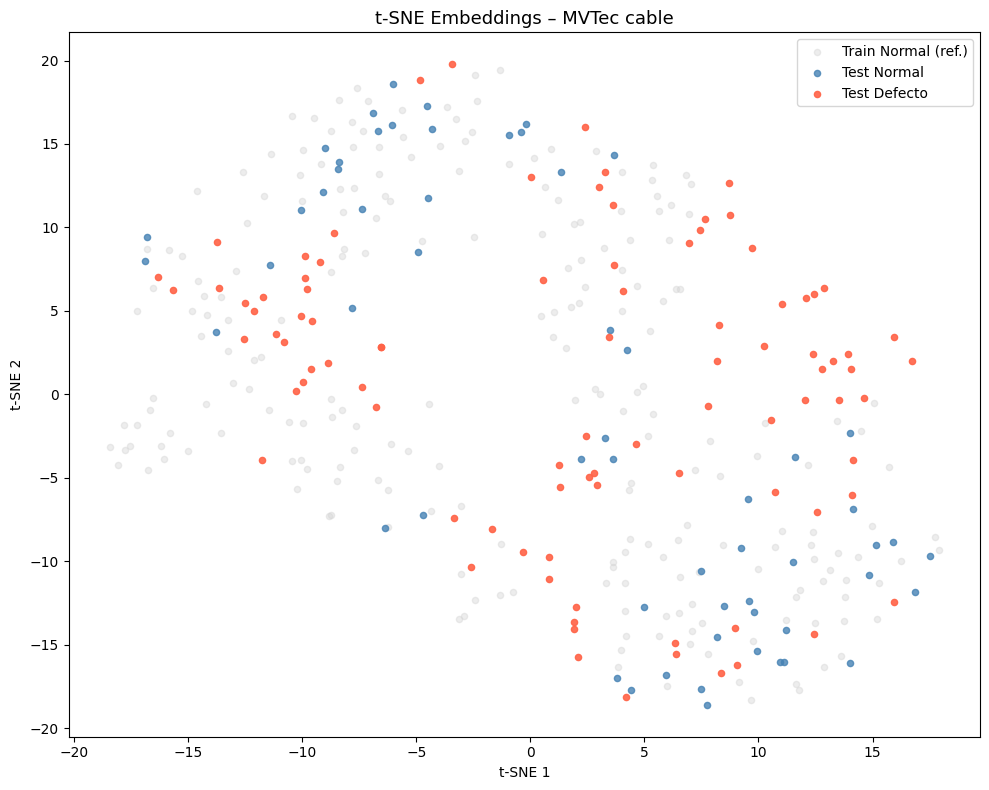

In [ ]:
# Combinar train (normales) + test para contexto
all_embs   = np.vstack([train_embs_scaled, test_embs_scaled])
all_labels = np.concatenate([
    np.full(len(train_embs_scaled), fill_value=2),  # 2 = train normal (referencia)
    test_labels
])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embs_2d = tsne.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(10, 8))

colores = {0: 'steelblue', 1: 'tomato', 2: 'lightgray'}
nombres  = {0: 'Test Normal', 1: 'Test Defecto', 2: 'Train Normal (ref.)'}
zorders  = {0: 3, 1: 4, 2: 1}
alphas   = {0: 0.8, 1: 0.9, 2: 0.4}

for lbl in [2, 0, 1]:
    mask = all_labels == lbl
    ax.scatter(
        embs_2d[mask, 0], embs_2d[mask, 1],
        c=colores[lbl], label=nombres[lbl],
        alpha=alphas[lbl], zorder=zorders[lbl], s=20
    )

ax.set_title(f't-SNE Embeddings – MVTec {cfg.category}', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Inferencia en imagen individual

Función para clasificar una imagen nueva como **Normal** o **Defecto**.

In [ ]:
def detectar_defecto(image_path: str, model, ocsvm, scaler, device) -> dict:
    """
    Clasifica una imagen como Normal o Defecto.

    Retorna:
        dict con 'prediccion', 'score' y 'embedding'
    """
    from PIL import Image

    img = Image.open(image_path).convert('RGB')
    img_t = transform_base(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        emb = model.forward_once(img_t).cpu().numpy()

    emb_scaled = scaler.transform(emb)
    score = ocsvm.decision_function(emb_scaled)[0]
    pred  = ocsvm.predict(emb_scaled)[0]

    return {
        'prediccion': 'Normal' if pred == 1 else '⚠ DEFECTO',
        'score': float(score),
        'embedding': emb,
    }


test_path = Path(cfg.mvtec_path) / cfg.category / 'test'

print("=== Ejemplo de inferencia ===")
for subdir in sorted(test_path.iterdir())[:3]:  # primeras 3 subcarpetas
    imgs = sorted(list(subdir.glob('*.png')) + list(subdir.glob('*.jpg')))
    if imgs:
        resultado = detectar_defecto(str(imgs[0]), model, ocsvm, scaler, device)
        print(
            f"  [{subdir.name:20s}] → {resultado['prediccion']:15s}  "
            f"score={resultado['score']:.4f}"
        )

=== Ejemplo de inferencia ===
  [bent_wire           ] → Normal           score=0.0533
  [cable_swap          ] → ⚠ DEFECTO        score=-0.0102
  [combined            ] → ⚠ DEFECTO        score=-0.0262
